In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pandas as pd

In [6]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Classical Functions (Dimesion = 100) [F1 - F13]

# Classical F14-F23

# CEC 2020

In [4]:
import pandas as pd

df = pd.read_csv(r'D:\ProfAjaz\Experiment#1\new_global_result\results_cec2020\cec2020_individual_runs_history.csv')

res = df.groupby('Optimizer').agg({
    'Best_Fitness': 'mean',
    'DStar_Early_5': 'mean',
    'Hussain_Early_5': 'mean',
    'DStar_Early_10': 'mean',
    'Hussain_Early_10': 'mean',
    'DStar_Mean_Expl': 'mean',
    'Hussain_Mean_Expl': 'mean'
}).reset_index()

res['Rank'] = res['Best_Fitness'].rank(ascending=True).astype(int)

res = res[[
    'Optimizer', 'Best_Fitness', 'Rank', 
    'DStar_Early_5', 'Hussain_Early_5', 
    'DStar_Early_10', 'Hussain_Early_10', 
    'DStar_Mean_Expl', 'Hussain_Mean_Expl'
]]

res.columns = [
    'Optimizer', 'Avg_Fitness', 'Rank', 
    'D* Early 5%', 'Hussain Early 5%', 
    'D* Early 10%', 'Hussain Early 10%', 
    'D* Total Expl', 'Hussain Total Expl'
]

res = res.sort_values('Rank')

print("--- COMPARISON TABLE: EXPLORATION VS PERFORMANCE ON CEC 2020 ---")
print(res.to_string(index=False))

res.to_csv('comparison_performance_exploration.csv', index=False)

--- COMPARISON TABLE: EXPLORATION VS PERFORMANCE ON CEC 2020 ---
Optimizer  Avg_Fitness  Rank  D* Early 5%  Hussain Early 5%  D* Early 10%  Hussain Early 10%  D* Total Expl  Hussain Total Expl
     AGOA 4.072732e+03     1    65.989930         67.907555     56.514592          58.072637      38.818631           39.889902
      EES 5.214362e+03     2    24.521386         28.565290     17.670481          20.519829       3.192004            3.661467
       DE 8.621330e+03     3    57.349659         55.275655     44.266980          42.398735      18.148623           16.941281
      GWO 1.980280e+08     4    37.658479         37.658479     34.214242          34.214242      15.477144           15.477144
      PSO 4.067271e+09     5     4.206883          4.204906      2.113028           2.112039       0.211303            0.211204


In [13]:
import pandas as pd

df = pd.read_csv(r'D:\ProfAjaz\Experiment#1\new_global_result\results_cec2020\cec2020_individual_runs_history.csv')

res = df.groupby('Optimizer').agg({
    'Best_Fitness': 'mean',
    'DStar_Mean_Expl': 'mean',
    'Hussain_Mean_Expl': 'mean',
    'DStar_Early_5': 'mean',
    'Hussain_Early_5': 'mean',
    'DStar_Early_10': 'mean',
    'Hussain_Early_10': 'mean',
    'DStar_Xover': 'mean',
    'Hussain_Xover': 'mean'
}).reset_index()

res['Rank'] = res['Best_Fitness'].rank(ascending=True).astype(int)
res = res.sort_values('Rank')

table_performance = res[[
    'Optimizer', 'Best_Fitness', 'Rank', 
    'DStar_Mean_Expl', 'Hussain_Mean_Expl'
]]
table_performance.columns = ['Optimizer', 'Avg. Fitness', 'Rank', 'Expl (D*)', 'Expl (Hussain)']

table_early_dynamics = res[[
    'Optimizer', 
    'DStar_Early_5', 'Hussain_Early_5', 
    'DStar_Early_10', 'Hussain_Early_10',
    'DStar_Xover', 'Hussain_Xover'
]]
table_early_dynamics.columns = [
    'Optimizer', 
    'E-5% (D*)', 'E-5% (H)', 
    'E-10% (D*)', 'E-10% (H)', 
    'Xover (D*)', 'Xover (H)'
]

print("--- TABLE A: PERFORMANCE & GLOBAL EXPLORATION ---")
print(table_performance.to_string(index=False))

print("\n--- TABLE B: EARLY DYNAMICS (5% & 10%) & CROSSOVER ---")
print(table_early_dynamics.to_string(index=False))

table_performance.to_csv('table_performance.csv', index=False)
table_early_dynamics.to_csv('table_early_dynamics.csv', index=False)

--- TABLE A: PERFORMANCE & GLOBAL EXPLORATION ---
Optimizer  Avg. Fitness  Rank  Expl (D*)  Expl (Hussain)
     AGOA  4.072732e+03     1  38.818631       39.889902
      EES  5.214362e+03     2   3.192004        3.661467
       DE  8.621330e+03     3  18.148623       16.941281
      GWO  1.980280e+08     4  15.477144       15.477144
      PSO  4.067271e+09     5   0.211303        0.211204

--- TABLE B: EARLY DYNAMICS (5% & 10%) & CROSSOVER ---
Optimizer  E-5% (D*)  E-5% (H)  E-10% (D*)  E-10% (H)  Xover (D*)  Xover (H)
     AGOA  65.989930 67.907555   56.514592  58.072637  312.413333 316.983333
      EES  24.521386 28.565290   17.670481  20.519829   19.610000  28.816667
       DE  57.349659 55.275655   44.266980  42.398735  271.310000 266.306667
      GWO  37.658479 37.658479   34.214242  34.214242    6.963333   6.963333
      PSO   4.206883  4.204906    2.113028   2.112039    1.410000   1.410000


Correlation: Crossover Point vs Final Fitness - R2 Score: 0.0085


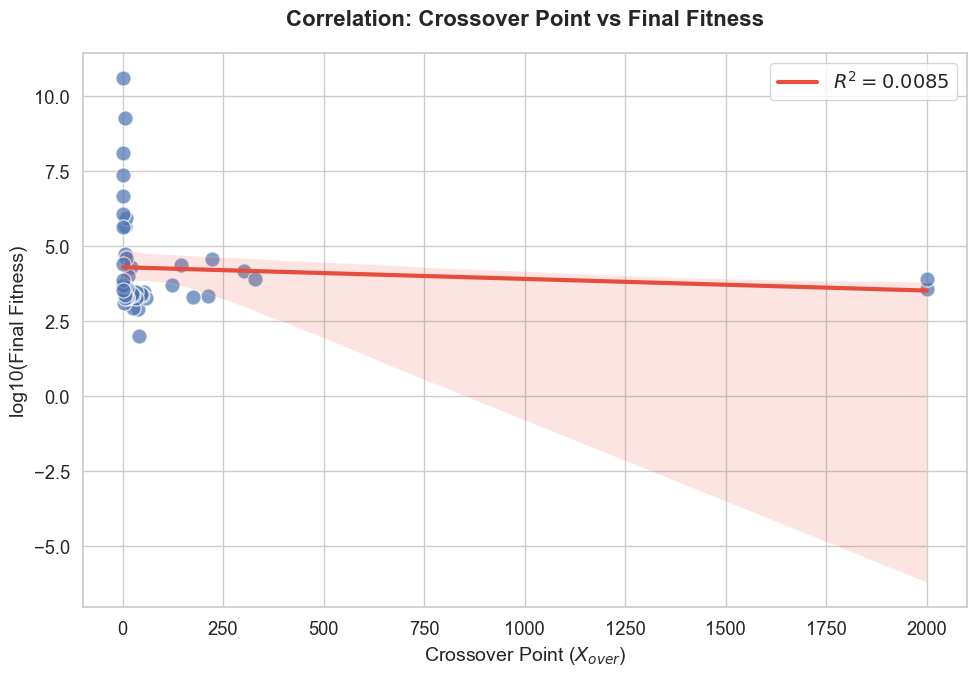

Mean Exploration vs Optimizer Rank - R2 Score: 0.4507


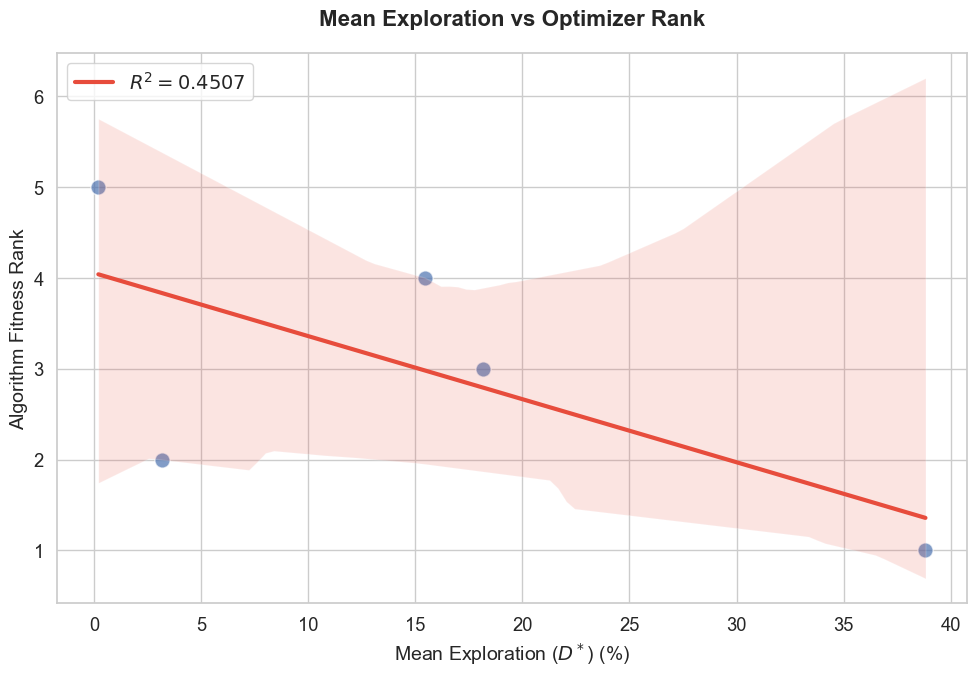

AUC vs Optimizer Rank - R2 Score: 0.4507


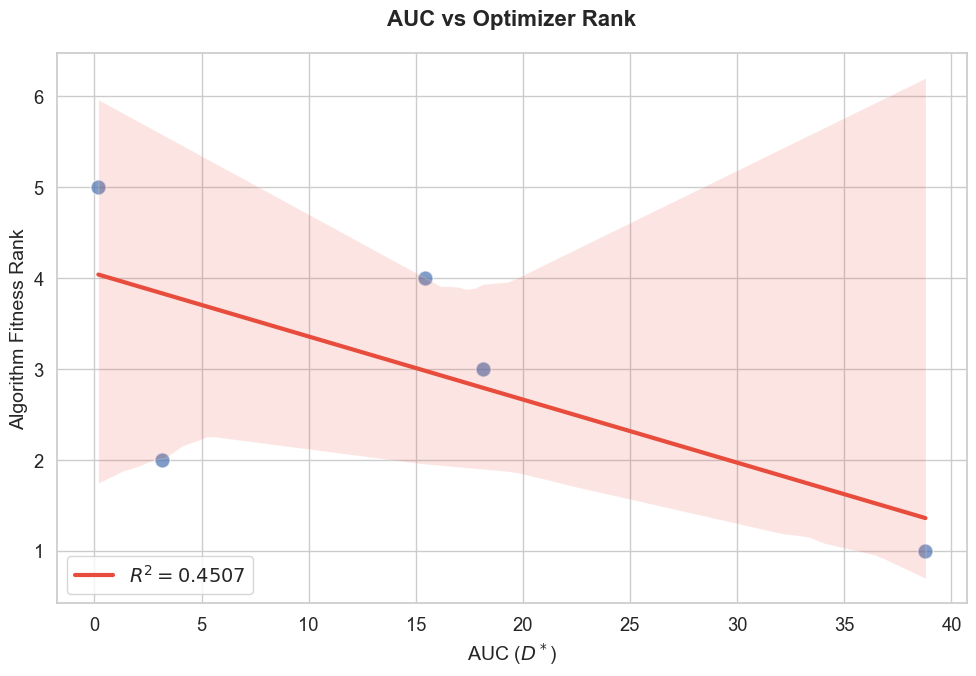

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

df = pd.read_csv(r'D:\ProfAjaz\Experiment#1\new_global_result\results_cec2020\cec2020_individual_runs_history.csv')

df_agg = df.groupby(['Optimizer', 'Function']).mean(numeric_only=True).reset_index()

df_rank = df_agg.groupby('Optimizer').mean(numeric_only=True).reset_index()
df_rank['Fitness_Rank'] = df_rank['Best_Fitness'].rank()

sns.set_theme(style="whitegrid", font_scale=1.2)

def plot_and_report(x_data, y_data, x_label, y_label, title, filename):
    plt.figure(figsize=(10, 7))
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
    r_squared = r_value**2
    
    print(f"{title} - R2 Score: {r_squared:.4f}")
    
    sns.regplot(x=x_data, y=y_data, 
                scatter_kws={'s': 120, 'alpha': 0.7, 'edgecolor': 'w'}, 
                line_kws={'color': '#e74c3c', 'linewidth': 3, 'label': f'$R^2 = {r_squared:.4f}$'})
    
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.xlabel(x_label, fontsize=14)
    plt.ylabel(y_label, fontsize=14)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

plot_and_report(
    df_agg['DStar_Xover'], 
    np.log10(df_agg['Best_Fitness']), 
    'Crossover Point ($X_{over}$)', 
    'log10(Final Fitness)', 
    'Correlation: Crossover Point vs Final Fitness', 
    'scatter_xover_vs_fitness.png'
)

plot_and_report(
    df_rank['DStar_Mean_Expl'], 
    df_rank['Fitness_Rank'], 
    'Mean Exploration ($D^*$) (%)', 
    'Algorithm Fitness Rank', 
    'Mean Exploration vs Optimizer Rank', 
    'scatter_mean_expl_vs_rank.png'
)

plot_and_report(
    df_rank['DStar_AUC_Expl'], 
    df_rank['Fitness_Rank'], 
    'AUC ($D^*$)', 
    'Algorithm Fitness Rank', 
    'AUC vs Optimizer Rank', 
    'scatter_auc_vs_rank.png'
)

Scatter: Early 5% Exploration vs Final Fitness - R2 Score: 0.1137


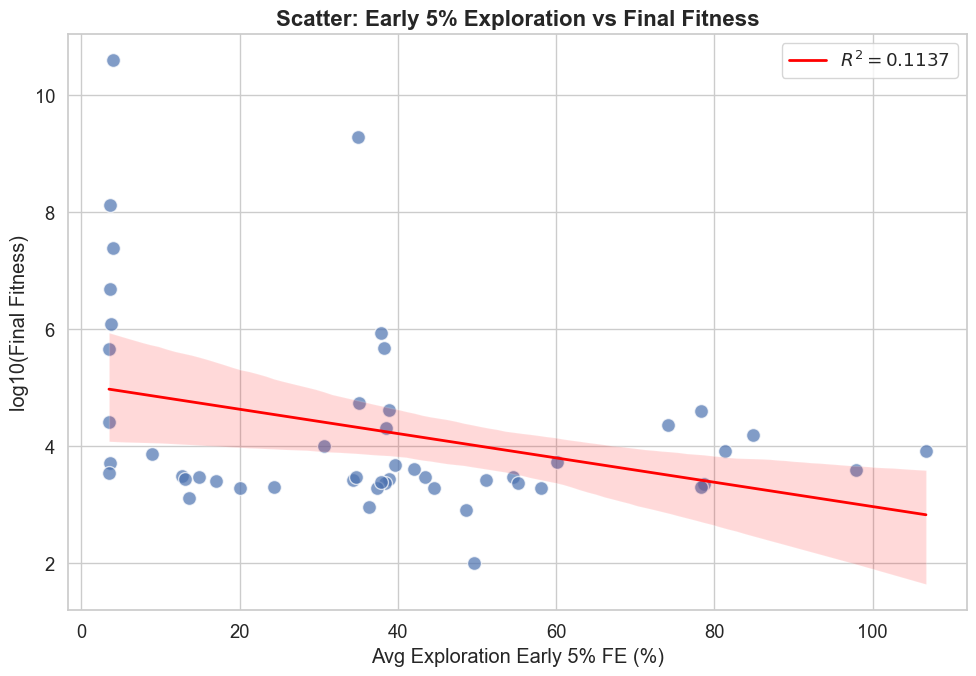

Scatter: Early 5% Exploration vs Time-to-Target - R2 Score: 0.3834


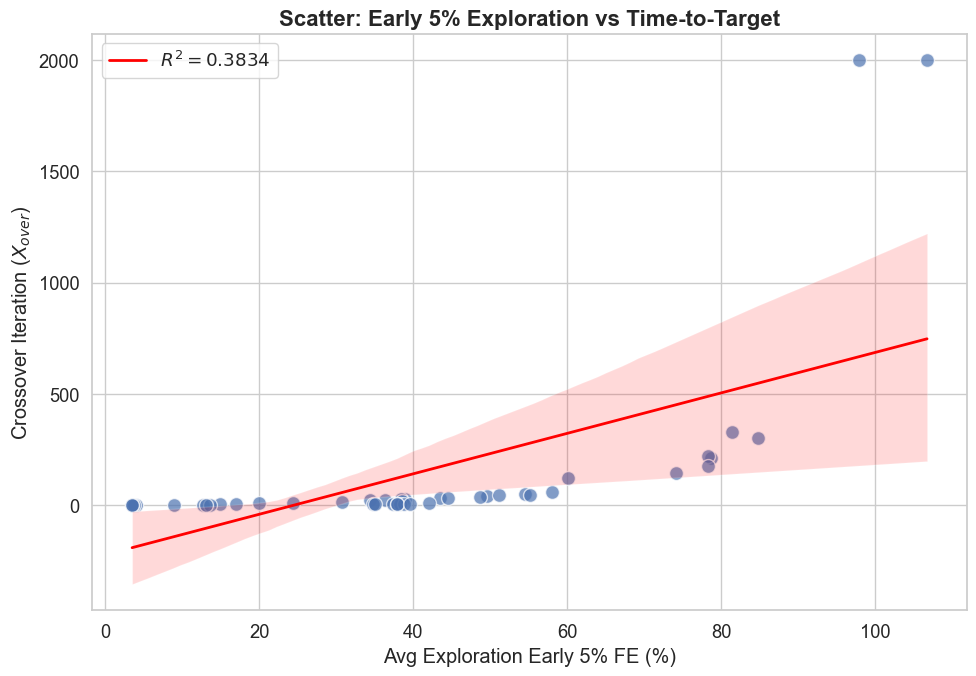

Scatter: Early 10% Exploration vs Final Fitness - R2 Score: 0.0713


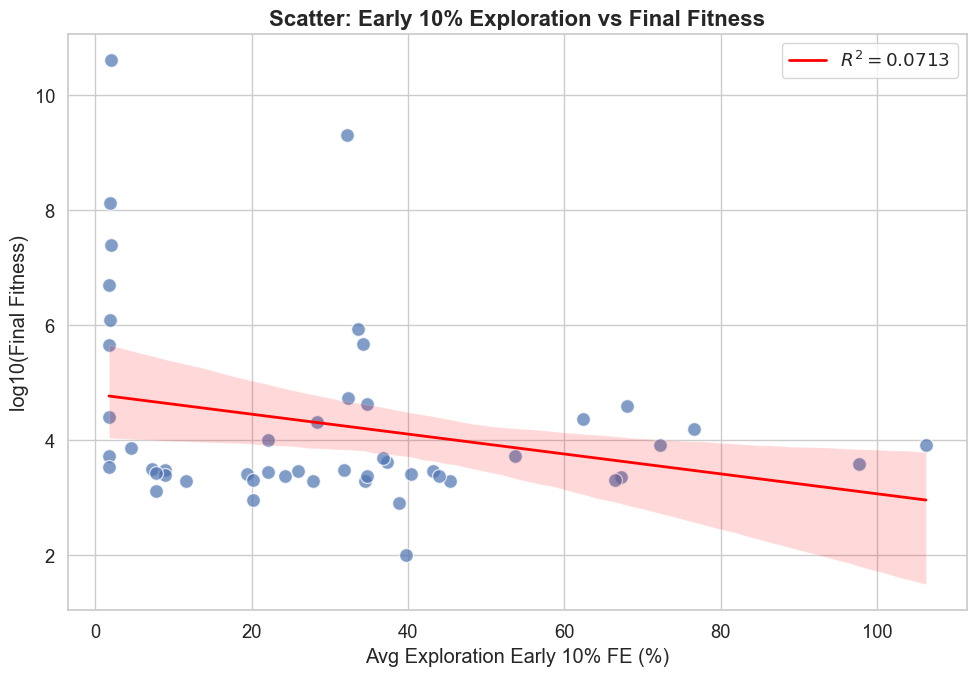

Scatter: Early 10% Exploration vs Time-to-Target - R2 Score: 0.4757


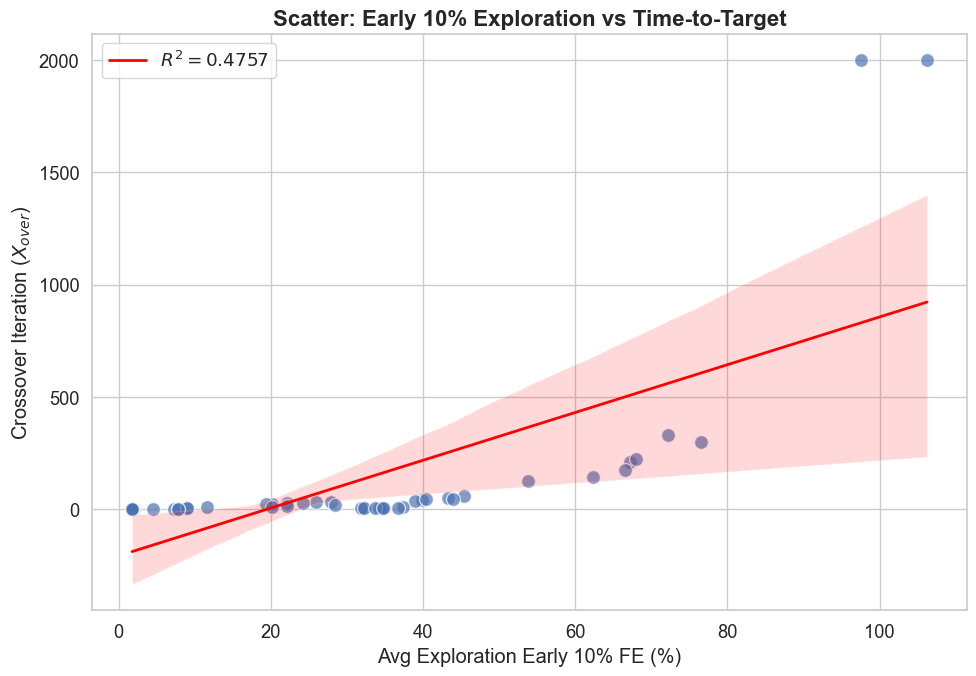

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

df = pd.read_csv(r'D:\ProfAjaz\Experiment#1\new_global_result\results_cec2020\cec2020_individual_runs_history.csv')

df_agg = df.groupby(['Optimizer', 'Function']).mean(numeric_only=True).reset_index()

sns.set_theme(style="whitegrid", font_scale=1.2)

def plot_scatter(x_data, y_data, x_label, y_label, title, filename):
    plt.figure(figsize=(10, 7))
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
    r_squared = r_value**2
    print(f"{title} - R2 Score: {r_squared:.4f}")
    sns.regplot(x=x_data, y=y_data, 
                scatter_kws={'s': 100, 'alpha': 0.7, 'edgecolor': 'w'}, 
                line_kws={'color': 'red', 'linewidth': 2, 'label': f'$R^2 = {r_squared:.4f}$'})
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

plot_scatter(df_agg['DStar_Early_5'], np.log10(df_agg['Best_Fitness']), 'Avg Exploration Early 5% FE (%)', 'log10(Final Fitness)', 'Scatter: Early 5% Exploration vs Final Fitness', 'scatter_early5_vs_fitness.png')
plot_scatter(df_agg['DStar_Early_5'], df_agg['DStar_Xover'], 'Avg Exploration Early 5% FE (%)', 'Crossover Iteration ($X_{over}$)', 'Scatter: Early 5% Exploration vs Time-to-Target', 'scatter_early5_vs_xover.png')
plot_scatter(df_agg['DStar_Early_10'], np.log10(df_agg['Best_Fitness']), 'Avg Exploration Early 10% FE (%)', 'log10(Final Fitness)', 'Scatter: Early 10% Exploration vs Final Fitness', 'scatter_early10_vs_fitness.png')
plot_scatter(df_agg['DStar_Early_10'], df_agg['DStar_Xover'], 'Avg Exploration Early 10% FE (%)', 'Crossover Iteration ($X_{over}$)', 'Scatter: Early 10% Exploration vs Time-to-Target', 'scatter_early10_vs_xover.png')

In [32]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

df = pd.read_csv(r'D:\ProfAjaz\Experiment#1\new_global_result\results_cec2020\cec2020_individual_runs_history.csv')

def bootstrap_ci(data, n_boot=1000, ci=95):
    boot_means = []
    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))
    return np.percentile(boot_means, (100-ci)/2), np.percentile(boot_means, 100-(100-ci)/2)

optimizers = df['Optimizer'].unique()
functions = df['Function'].unique()
algo_means = []

print(f"{'Optimizer':<12} | {'Mean Rho':<10} | {'Min Rho':<10}")
print("-" * 40)

for opt in optimizers:
    opt_rhos = []
    subset_opt = df[df['Optimizer'] == opt]
    for func in functions:
        subset = subset_opt[subset_opt['Function'] == func]
        if len(subset) > 1:
            rho, _ = spearmanr(subset['DStar_Mean_Expl'], subset['Hussain_Mean_Expl'])
            if not np.isnan(rho):
                opt_rhos.append(rho)
    
    if opt_rhos:
        m_rho = np.mean(opt_rhos)
        min_rho = np.min(opt_rhos)
        algo_means.append(m_rho)
        print(f"{opt:<12} | {m_rho:<10.4f} | {min_rho:<10.4f}")

final_global_rho = np.mean(algo_means)
iqr_q1, iqr_q3 = np.percentile(algo_means, [25, 75])
ci_low, ci_high = bootstrap_ci(algo_means)

print("-" * 40)
print(f"OVERALL MARKER (Mean of Algos): {final_global_rho:.4f}")
print(f"IQR Across Algos              : [{iqr_q1:.4f}, {iqr_q3:.4f}]")
print(f"95% Bootstrap CI              : ({ci_low:.4f}, {ci_high:.4f})")
print(f"STATUS                        : {'NON-REDUNDANT (<0.95)' if final_global_rho < 0.95 else 'REDUNDANT'}")

Optimizer    | Mean Rho   | Min Rho   
----------------------------------------
GWO          | 1.0000     | 1.0000    
PSO          | 1.0000     | 1.0000    
DE           | 0.9631     | 0.8759    
AGOA         | 0.7317     | 0.3130    
EES          | 0.7972     | 0.3010    
----------------------------------------
OVERALL MARKER (Mean of Algos): 0.8984
IQR Across Algos              : [0.7972, 1.0000]
95% Bootstrap CI              : (0.7985, 0.9926)
STATUS                        : NON-REDUNDANT (<0.95)


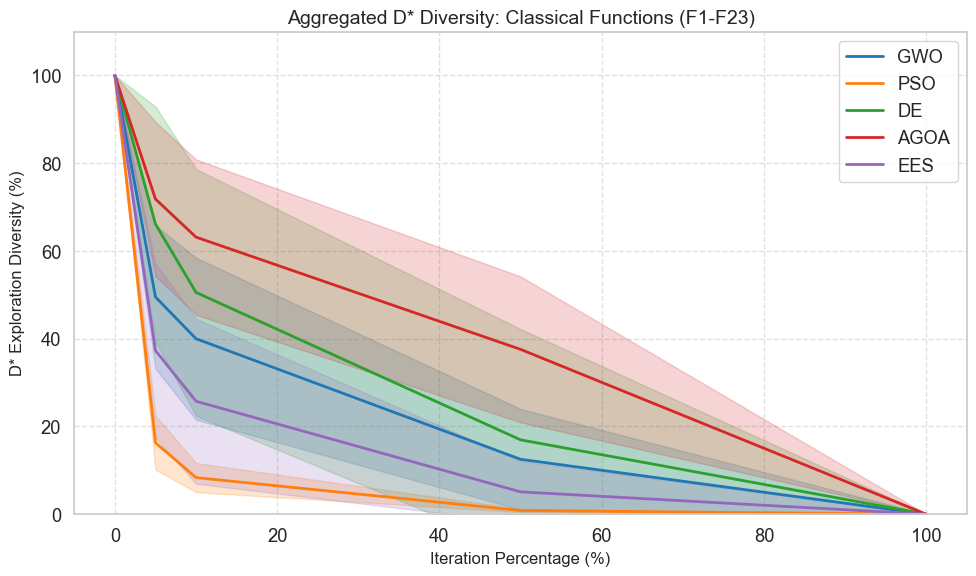

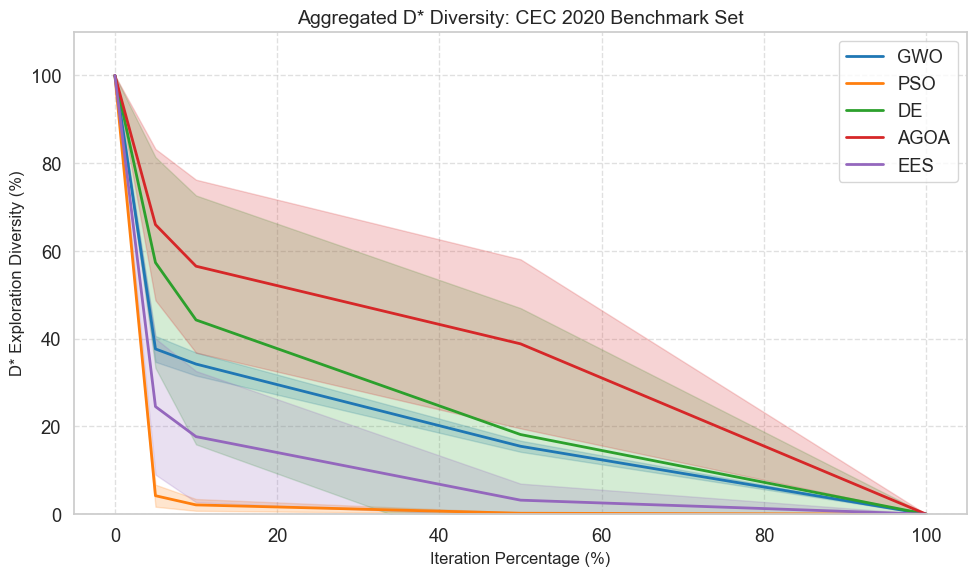

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_and_prepare_data(path):
    return pd.read_csv(path)

path_cec = r'D:\ProfAjaz\Experiment#1\new_global_result\results_cec2020\cec2020_individual_runs_history.csv'
path_f1_13 = r'D:\ProfAjaz\Experiment#1\new_global_result\results_f1_f13\individual_runs_history.csv'
path_f14_23 = r'D:\ProfAjaz\Experiment#1\new_global_result\results_f14_f23\individual_runs_history.csv'

df_cec = load_and_prepare_data(path_cec)
df_f1_13 = load_and_prepare_data(path_f1_13)
df_f14_23 = load_and_prepare_data(path_f14_23)

df_classic = pd.concat([df_f1_13, df_f14_23], ignore_index=True)

def plot_diversity_curves(data, title, filename):
    plt.figure(figsize=(10, 6))
    optimizers = data['Optimizer'].unique()
    
    # Asumsi sumbu X adalah persentase iterasi (0-100%)
    # Karena data di CSV adalah ringkasan per Run, kita memetakan fase Early_5, Early_10, Xover, dan Mean
    # untuk membentuk profil kurva estimasi
    x_points = np.array([0, 5, 10, 50, 100])
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for idx, opt in enumerate(optimizers):
        subset = data[data['Optimizer'] == opt]
        
        # Menghitung titik-titik koordinat untuk kurva
        y_start = 100
        y_5 = subset['DStar_Early_5'].mean()
        y_10 = subset['DStar_Early_10'].mean()
        y_mid = subset['DStar_Mean_Expl'].mean()
        y_end = 0 # Asumsi di akhir iterasi eksplorasi menuju 0
        
        y_points = np.array([y_start, y_5, y_10, y_mid, y_end])
        
        # Menghitung STD untuk pita (shade)
        std_5 = subset['DStar_Early_5'].std()
        std_10 = subset['DStar_Early_10'].std()
        std_mid = subset['DStar_Mean_Expl'].std()
        y_std = np.array([0, std_5, std_10, std_mid, 0])
        
        plt.plot(x_points, y_points, label=opt, color=colors[idx], linewidth=2)
        plt.fill_between(x_points, y_points - y_std, y_points + y_std, color=colors[idx], alpha=0.2)

    plt.title(title, fontsize=14)
    plt.xlabel('Iteration Percentage (%)', fontsize=12)
    plt.ylabel('D* Exploration Diversity (%)', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.ylim(0, 110)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

plot_diversity_curves(df_classic, 'Aggregated D* Diversity: Classical Functions (F1-F23)', 'diversity_classic.png')



plot_diversity_curves(df_cec, 'Aggregated D* Diversity: CEC 2020 Benchmark Set', 'diversity_cec2020.png')